**IMPORTS**

In [9]:

import os, random, cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))




TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**LOAD DATASET FROM KAGGLE**

In [ ]:
import json

#CONFIG
KAGGLE_USERNAME = "USERNAME" # USE KAGGLE USERNAME
KAGGLE_KEY      = "KEY"   # GENERATE API KEY

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.system("chmod 600 ~/.kaggle/kaggle.json")


os.system(
    "kaggle datasets download -d ravirajsinh45/"
    "real-life-industrial-dataset-of-casting-product --unzip"
)

for root, dirs, files_ in os.walk("casting_data"):
    level = root.replace("casting_data", "").count(os.sep)
    print("  " * level + os.path.basename(root) + f"/  ({len(files_)} files)")

casting_data/  (0 files)
  casting_data/  (0 files)
    train/  (0 files)
      def_front/  (3758 files)
      ok_front/  (2875 files)
    test/  (0 files)
      def_front/  (453 files)
      ok_front/  (262 files)


**CONFIGURATION**

In [ ]:
DATA_DIR = "casting_data/casting_data"
IMG_SIZE   = (300, 300)
BATCH_SIZE = 32
EPOCHS     = 25
SEED       = 42

CLASS_NAMES = ["Defective", "OK"]

**DATA GENERATORS**

In [ ]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    brightness_range=[0.85, 1.15],
    shear_range=0.1,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    subset="training",
    shuffle=True,
    seed=SEED,
)


val_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    subset="validation",
    shuffle=False,
    seed=SEED,
)


test_gen = test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "test"),
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
)

print(f"Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")

Found 5307 images belonging to 2 classes.
Found 1326 images belonging to 2 classes.
Found 715 images belonging to 2 classes.
Train: 5307 | Val: 1326 | Test: 715


**MODEL ARCHITECTURE**

In [10]:
tf.keras.backend.clear_session()

def build_model_fixed(input_shape=(300, 300, 1)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation="relu", padding="same",
                      input_shape=input_shape, name="block1_conv"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), activation="relu", padding="same",
                      name="block2_conv"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3,3), activation="relu", padding="same",
                      name="last_conv"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid", name="predictions"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_model_fixed()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv (Conv2D)            │ (None, 300, 300, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 300, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv (Conv2D)            │ (None, 150, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,849 (495.50 KB)

 Trainable params: 126,401 (493.75 KB)

 Non-trainable params: 448 (1.75 KB)

**TRAINING**

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model.h5", monitor="val_loss",
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
]

history = model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.6629 - loss: 0.6117
Epoch 1: val_loss improved from None to 0.67382, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 97s 498ms/step - accuracy: 0.6738 - loss: 0.6012 - val_accuracy: 0.6071 - val_loss: 0.6738 - learning_rate: 1.0000e-04
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.7271 - loss: 0.5538
Epoch 2: val_loss improved from 0.67382 to 0.65085, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 66s 398ms/step - accuracy: 0.7221 - loss: 0.5581 - val_accuracy: 0.6418 - val_loss: 0.6508 - learning_rate: 1.0000e-04
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.7565 - loss: 0.5157
Epoch 3: val_loss improved from 0.65085 to 0.60336, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 67s 401ms/step - accuracy: 0.7695 - loss: 0.4993 - val_accuracy: 0.6614 - val_loss: 0.6034 - learning_rate: 1.0000e-04
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.7737 - loss: 0.4830
Epoch 4: val_loss did not improve from 0.60336
166/166 ━━━━━━━━━━━━━━━━━━━━ 66s 397ms/step - accuracy: 0.7916 - loss: 0.4597 - val_accuracy: 0.6440 - val_loss: 0.6120 - learning_rate: 1.0000e-04
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.8240 - loss: 0.4078
Epoch 5: val_loss improved from 0.60336 to 0.48281, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 66s 398ms/step - accuracy: 0.8329 - loss: 0.3952 - val_accuracy: 0.7640 - val_loss: 0.4828 - learning_rate: 1.0000e-04
Epoch 6/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.8632 - loss: 0.3530
Epoch 6: val_loss did not improve from 0.48281
166/166 ━━━━━━━━━━━━━━━━━━━━ 66s 399ms/step - accuracy: 0.8613 - loss: 0.3456 - val_accuracy: 0.6757 - val_loss: 0.6135 - learning_rate: 1.0000e-04
Epoch 7/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.8721 - loss: 0.3134
Epoch 7: val_loss improved from 0.48281 to 0.26702, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 64s 386ms/step - accuracy: 0.8815 - loss: 0.3012 - val_accuracy: 0.9020 - val_loss: 0.2670 - learning_rate: 1.0000e-04
Epoch 8/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.8967 - loss: 0.2671
Epoch 8: val_loss did not improve from 0.26702
166/166 ━━━━━━━━━━━━━━━━━━━━ 63s 382ms/step - accuracy: 0.8969 - loss: 0.2676 - val_accuracy: 0.8409 - val_loss: 0.3270 - learning_rate: 1.0000e-04
Epoch 9/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.9027 - loss: 0.2488
Epoch 9: val_loss did not improve from 0.26702
166/166 ━━━━━━━━━━━━━━━━━━━━ 64s 385ms/step - accuracy: 0.9035 - loss: 0.2411 - val_accuracy: 0.5671 - val_loss: 1.4023 - learning_rate: 1.0000e-04
Epoch 10/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9292 - loss: 0.2067
Epoch 10: val_loss did not improve from 0.26702

Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
166/166 ━━━━━━━━━━━━━━


Epoch 12: finished saving model to best_model.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 62s 375ms/step - accuracy: 0.9337 - loss: 0.1880 - val_accuracy: 0.9683 - val_loss: 0.1344 - learning_rate: 5.0000e-05
Epoch 13/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9537 - loss: 0.1572
Epoch 13: val_loss improved from 0.13441 to 0.12744, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 62s 376ms/step - accuracy: 0.9506 - loss: 0.1595 - val_accuracy: 0.9698 - val_loss: 0.1274 - learning_rate: 5.0000e-05
Epoch 14/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9494 - loss: 0.1583
Epoch 14: val_loss did not improve from 0.12744
166/166 ━━━━━━━━━━━━━━━━━━━━ 63s 377ms/step - accuracy: 0.9440 - loss: 0.1653 - val_accuracy: 0.8688 - val_loss: 0.2650 - learning_rate: 5.0000e-05
Epoch 15/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9560 - loss: 0.1463
Epoch 15: val_loss did not improve from 0.12744
166/166 ━━━━━━━━━━━━━━━━━━━━ 71s 431ms/step - accuracy: 0.9544 - loss: 0.1464 - val_accuracy: 0.7489 - val_loss: 0.5008 - learning_rate: 5.0000e-05
Epoch 16/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.9425 - loss: 0.1509
Epoch 16: val_loss did not improve from 0.12744

Epoch 16: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
166/166 ━━━━━━━━━


Epoch 19: finished saving model to best_model.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 62s 372ms/step - accuracy: 0.9634 - loss: 0.1188 - val_accuracy: 0.9804 - val_loss: 0.0918 - learning_rate: 2.5000e-05
Epoch 20/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9617 - loss: 0.1188
Epoch 20: val_loss did not improve from 0.09175
166/166 ━━━━━━━━━━━━━━━━━━━━ 62s 373ms/step - accuracy: 0.9650 - loss: 0.1174 - val_accuracy: 0.9321 - val_loss: 0.1741 - learning_rate: 2.5000e-05
Epoch 21/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9669 - loss: 0.1191
Epoch 21: val_loss did not improve from 0.09175
166/166 ━━━━━━━━━━━━━━━━━━━━ 62s 375ms/step - accuracy: 0.9674 - loss: 0.1130 - val_accuracy: 0.8997 - val_loss: 0.2089 - learning_rate: 2.5000e-05
Epoch 22/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9727 - loss: 0.1005
Epoch 22: val_loss did not improve from 0.09175

Epoch 22: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
166/166 ━━━━━━━━━


Epoch 24: finished saving model to best_model.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 61s 367ms/step - accuracy: 0.9770 - loss: 0.0924 - val_accuracy: 0.9811 - val_loss: 0.0788 - learning_rate: 1.2500e-05
Epoch 25/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9799 - loss: 0.0910
Epoch 25: val_loss did not improve from 0.07884
166/166 ━━━━━━━━━━━━━━━━━━━━ 62s 375ms/step - accuracy: 0.9785 - loss: 0.0949 - val_accuracy: 0.9585 - val_loss: 0.1276 - learning_rate: 1.2500e-05
Restoring model weights from the end of the best epoch: 24.


**TRAINING CURVES**

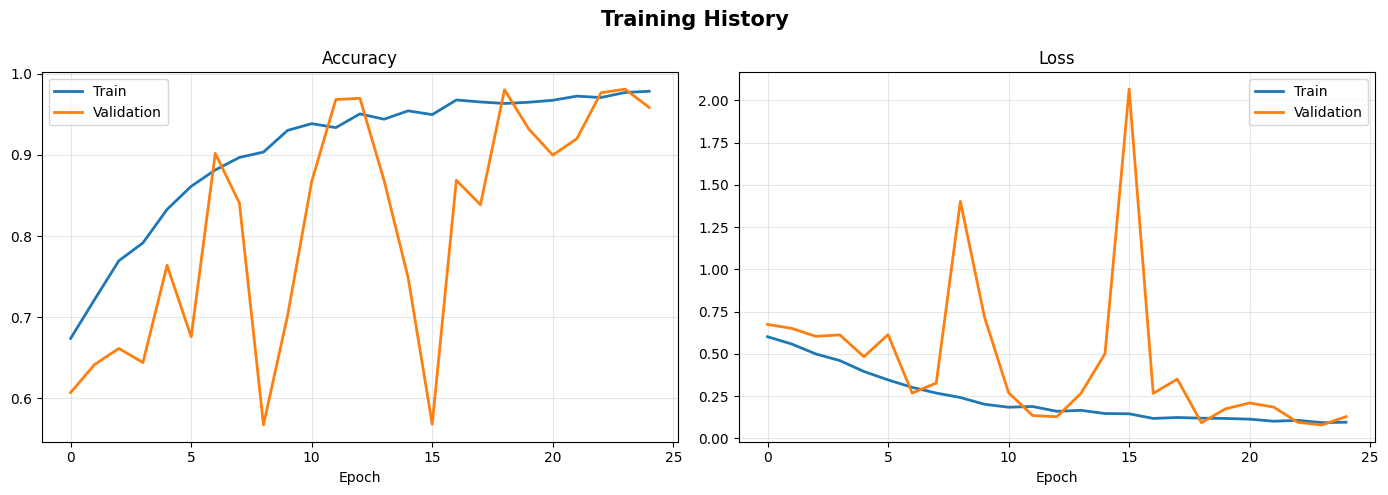

Saved: training_curves.png


In [ ]:
def plot_training_curves(history, save_path="training_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training History", fontsize=15, fontweight="bold")

    # Accuracy
    axes[0].plot(history.history["accuracy"],     label="Train",      linewidth=2)
    axes[0].plot(history.history["val_accuracy"], label="Validation", linewidth=2)
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history["loss"],     label="Train",      linewidth=2)
    axes[1].plot(history.history["val_loss"], label="Validation", linewidth=2)
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

plot_training_curves(history)

**EVALUATION**


CLASSIFICATION REPORT
              precision    recall  f1-score   support

          OK       1.00      0.85      0.92       262
   Defective       0.92      1.00      0.96       453

    accuracy                           0.94       715
   macro avg       0.96      0.92      0.94       715
weighted avg       0.95      0.94      0.94       715



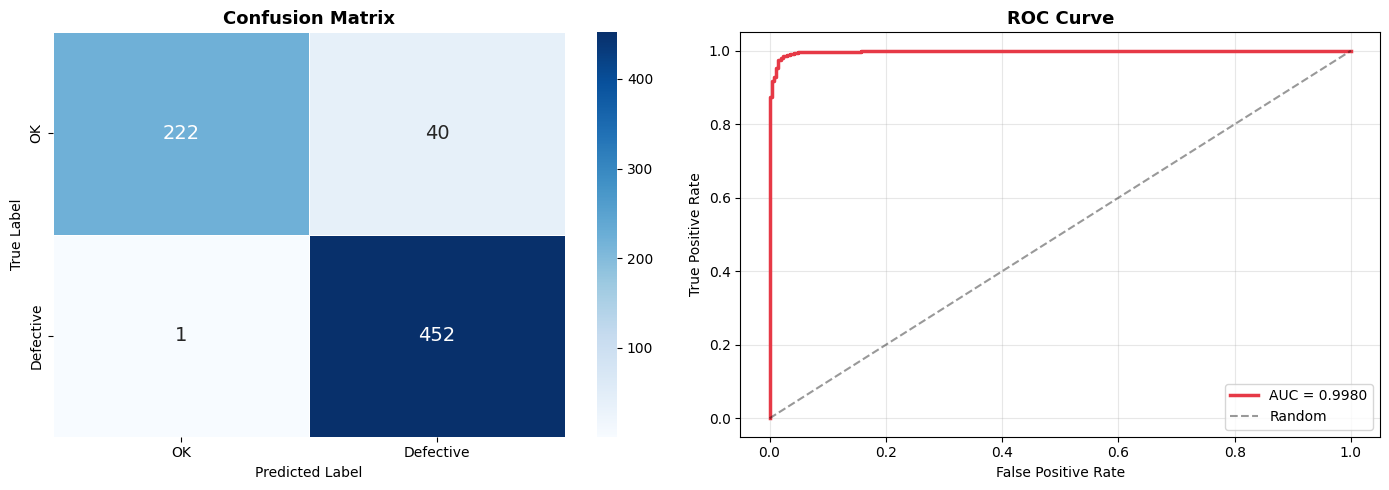

Saved: evaluation.png


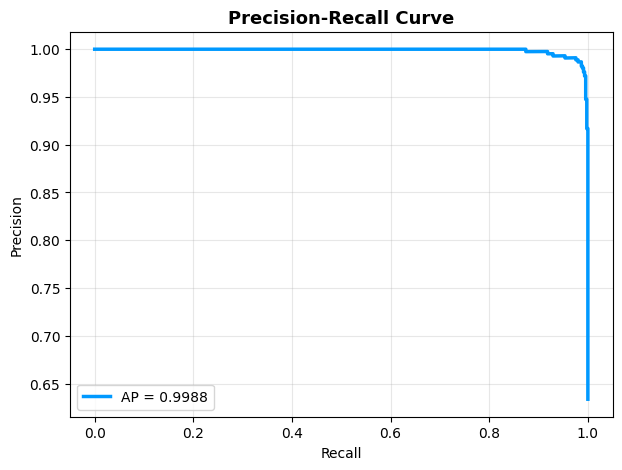

Saved: precision_recall.png

AUC-ROC : 0.9980
Avg Precision: 0.9988


In [ ]:

def evaluate_model(model, test_gen, save_prefix=""):
    # Raw predictions (probability of ok_front in Keras ordering)
    y_prob_ok = model.predict(test_gen, verbose=0).flatten()
    y_prob_defect = 1.0 - y_prob_ok          # defect probability

    # True labels: Keras gives 0=def_front,1=ok_front → flip to 0=OK, 1=Defective
    y_true_keras = test_gen.classes
    y_true = 1 - y_true_keras                # 0=OK, 1=Defective

    # Predicted class (threshold 0.5 on defect probability)
    y_pred = (y_prob_defect >= 0.5).astype(int)

    # Classification report
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=["OK", "Defective"]))

    #  Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["OK", "Defective"],
                yticklabels=["OK", "Defective"],
                ax=axes[0], linewidths=0.5, annot_kws={"size": 14})
    axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("True Label"); axes[0].set_xlabel("Predicted Label")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_prob_defect)
    auc_score   = roc_auc_score(y_true, y_prob_defect)
    axes[1].plot(fpr, tpr, linewidth=2.5, color="#e63946",
                 label=f"AUC = {auc_score:.4f}")
    axes[1].plot([0,1],[0,1], "k--", alpha=0.4, label="Random")
    axes[1].set_title("ROC Curve", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    path = f"{save_prefix}evaluation.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(y_true, y_prob_defect)
    ap = average_precision_score(y_true, y_prob_defect)

    plt.figure(figsize=(7, 5))
    plt.plot(rec, prec, linewidth=2.5, color="#0099ff", label=f"AP = {ap:.4f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision-Recall Curve", fontsize=13, fontweight="bold")
    plt.legend(); plt.grid(True, alpha=0.3)
    pr_path = f"{save_prefix}precision_recall.png"
    plt.savefig(pr_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {pr_path}")

    print(f"\nAUC-ROC : {auc_score:.4f}")
    print(f"Avg Precision: {ap:.4f}")

    return y_prob_defect, y_pred, y_true

y_prob_defect, y_pred, y_true = evaluate_model(model, test_gen)

**SEVERITY SCORING**


SEVERITY DISTRIBUTION — TEST SET
------------------------------------------
  PASS        223 ( 31.2%)  █████████
  LOW          24 (  3.4%)  █
  MODERATE     17 (  2.4%)  
  CRITICAL    451 ( 63.1%)  ██████████████████


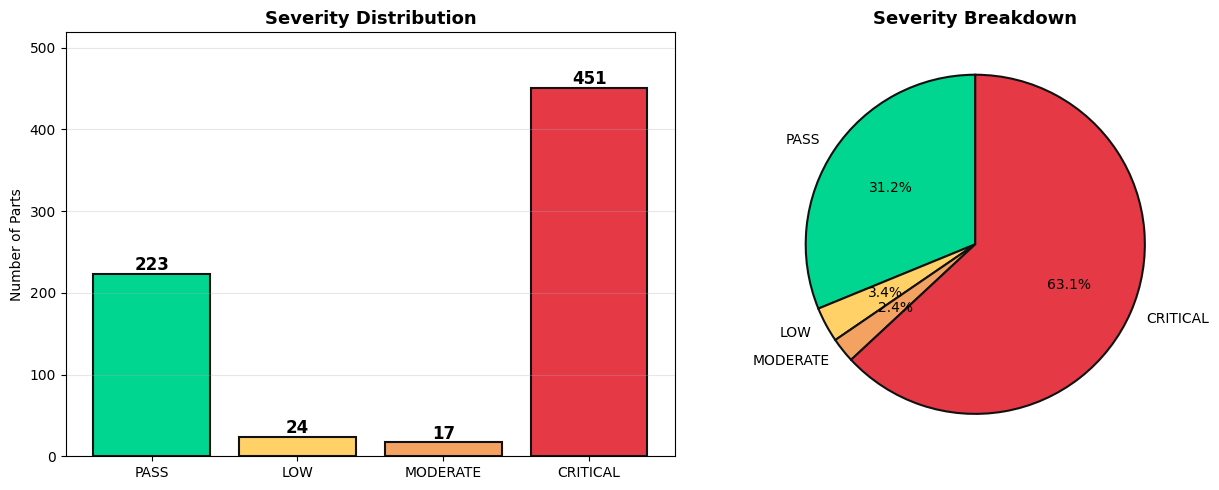

Saved: severity_distribution.png


In [ ]:

# Maps defect confidence (0-100%) to a severity tier.
# Thresholds are tunable based on production tolerance requirements.
#
#   PASS     : predicted OK  (defect confidence < 50%)
#   LOW      : 50% – 69%    → monitor, re-inspect at next checkpoint
#   MODERATE : 70% – 89%    → flag for manual human inspection
#   CRITICAL : 90% – 100%   → reject immediately, consider line halt
#
# Each tier outputs a concrete recommendation for the production engineer.

SEVERITY_THRESHOLDS = {
    "PASS":     (0.00, 0.50),
    "LOW":      (0.50, 0.70),
    "MODERATE": (0.70, 0.90),
    "CRITICAL": (0.90, 1.00),
}

SEVERITY_COLORS = {
    "PASS":     "#00d68f",
    "LOW":      "#ffd166",
    "MODERATE": "#f4a261",
    "CRITICAL": "#e63946",
}

SEVERITY_ACTIONS = {
    "PASS":     "Clear for shipment.",
    "LOW":      "Monitor — re-inspect at next quality checkpoint.",
    "MODERATE": "Flag for manual inspection before proceeding.",
    "CRITICAL": "Reject immediately. Review process parameters.",
}


def assign_severity(defect_prob):
    """
    Given a defect probability (0.0–1.0), return severity tier string.
    """
    if defect_prob < 0.50: return "PASS"
    if defect_prob < 0.70: return "LOW"
    if defect_prob < 0.90: return "MODERATE"
    return "CRITICAL"


def compute_severity_batch(y_prob_defect):
    """
    Compute severity for an array of defect probabilities.
    Returns list of dicts.
    """
    results = []
    for prob in y_prob_defect:
        sev = assign_severity(float(prob))
        results.append({
            "defect_confidence_pct": round(float(prob) * 100, 1),
            "severity": sev,
            "action": SEVERITY_ACTIONS[sev],
        })
    return results


severity_results = compute_severity_batch(y_prob_defect)


from collections import Counter
sev_counts = Counter(r["severity"] for r in severity_results)

print("\nSEVERITY DISTRIBUTION — TEST SET")
print("-" * 42)
total = len(severity_results)
for tier in ["PASS", "LOW", "MODERATE", "CRITICAL"]:
    n = sev_counts.get(tier, 0)
    bar = "█" * int(n / total * 30)
    print(f"  {tier:10s} {n:4d} ({n/total*100:5.1f}%)  {bar}")

labels = ["PASS", "LOW", "MODERATE", "CRITICAL"]
counts = [sev_counts.get(l, 0) for l in labels]
colors = [SEVERITY_COLORS[l] for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


bars = axes[0].bar(labels, counts, color=colors, edgecolor="#111", linewidth=1.5)
for bar, n in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(counts)*0.01,
                 str(n), ha="center", fontweight="bold", fontsize=12)
axes[0].set_title("Severity Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Parts")
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].grid(axis="y", alpha=0.3)


non_zero = [(l, c) for l, c in zip(labels, counts) if c > 0]
axes[1].pie(
    [c for _, c in non_zero],
    labels=[l for l, _ in non_zero],
    colors=[SEVERITY_COLORS[l] for l, _ in non_zero],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "#111", "linewidth": 1.5},
)
axes[1].set_title("Severity Breakdown", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("severity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: severity_distribution.png")

**DEFECT PROBABILITY DISTRIBUTION**

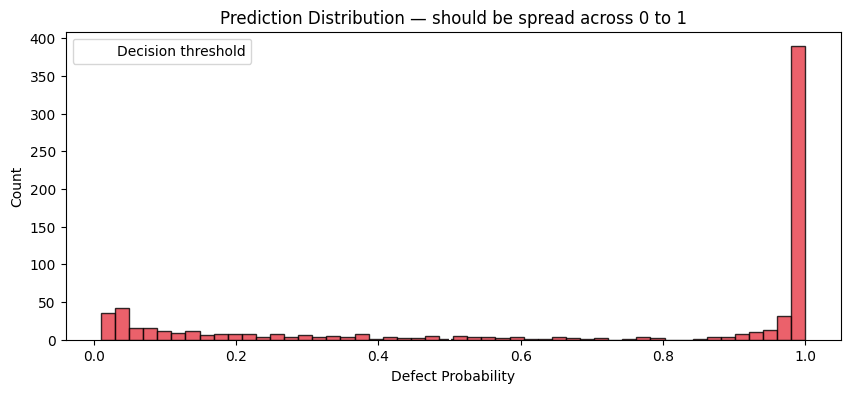

In [ ]:
y_prob_ok  = model.predict(test_gen, verbose=0).flatten()
y_prob_def = 1.0 - y_prob_ok

plt.figure(figsize=(10, 4))
plt.hist(y_prob_def, bins=50, color="#e63946", edgecolor="black", alpha=0.8)
plt.axvline(0.5, color="white", linestyle="--", label="Decision threshold")
plt.xlabel("Defect Probability"); plt.ylabel("Count")
plt.title("Prediction Distribution — should be spread across 0 to 1")
plt.legend(); plt.show()

**CONFUSION MATRIX**

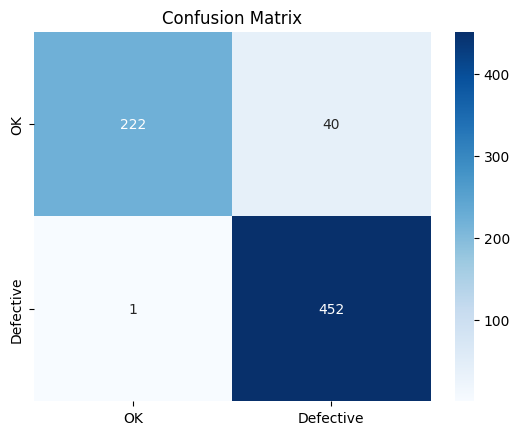

              precision    recall  f1-score   support

          OK       1.00      0.85      0.92       262
   Defective       0.92      1.00      0.96       453

    accuracy                           0.94       715
   macro avg       0.96      0.92      0.94       715
weighted avg       0.95      0.94      0.94       715



In [ ]:
y_pred = (y_prob_def >= 0.5).astype(int)
y_true = 1 - test_gen.classes   # flip Keras labels

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["OK","Defective"],
            yticklabels=["OK","Defective"])
plt.title("Confusion Matrix"); plt.show()

print(classification_report(y_true, y_pred, target_names=["OK","Defective"]))

**GRAD CAM IMPLEMENTATION**

In [ ]:
# Grad CAM (Gradient weighted Class Activation Mapping) answers:

# How it works:
#   1. Forward pass → get activations from last conv layer + final prediction
#   2. Compute gradient of the predicted class score w.r.t. each feature map
#   3. Pool gradients spatially → importance weights per filter
#   4. Weighted sum of feature maps → heatmap
#   5. Upsample heatmap to original image size
#   6. Overlay on image with colour mapping (blue=low, red=high activation)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="last_conv"):
    """
    Generate Grad-CAM heatmap for a single preprocessed image.

    Args:
        img_array : np.array of shape (1, H, W, 1), values in [0,1]
        model     : trained Keras model
        last_conv_layer_name : name of the target conv layer

    Returns:
        heatmap : np.array of shape (H_conv, W_conv), values in [0,1]
    """
    # Sub-model: maps input → (last conv output, final predictions)
    grad_model = Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output,
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # For binary sigmoid: class score IS the output neuron
        class_score = predictions[:, 0]

    # Gradient of class score w.r.t. conv feature maps
    grads = tape.gradient(class_score, conv_outputs)

    # Mean gradient per filter → importance weight
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))   # shape: (n_filters,)

    # Weighted combination of feature maps
    conv_outputs = conv_outputs[0]                          # (H, W, n_filters)
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]  # (H, W, 1)
    heatmap = tf.squeeze(heatmap)                           # (H, W)

    # ReLU + normalize to [0,1]
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(original_img_gray, heatmap, alpha=0.45):
    """
    Overlay Grad-CAM heatmap on the original grayscale image.

    Args:
        original_img_gray : np.array (H, W) or (H, W, 1), values in [0,1]
        heatmap           : np.array (H_cam, W_cam), values in [0,1]
        alpha             : heatmap opacity (0=invisible, 1=fully opaque)

    Returns:
        overlay_rgb : np.array (H, W, 3), uint8
    """
    # Convert grayscale to BGR for OpenCV
    gray_uint8 = (original_img_gray.squeeze() * 255).astype(np.uint8)
    img_bgr = cv2.cvtColor(gray_uint8, cv2.COLOR_GRAY2BGR)

    # Resize heatmap to match image
    H, W = gray_uint8.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (W, H))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    # Blend
    overlay = cv2.addWeighted(img_bgr, 1 - alpha, heatmap_colored, alpha, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)   # return RGB for matplotlib

**GRAD CAM RESULTS**

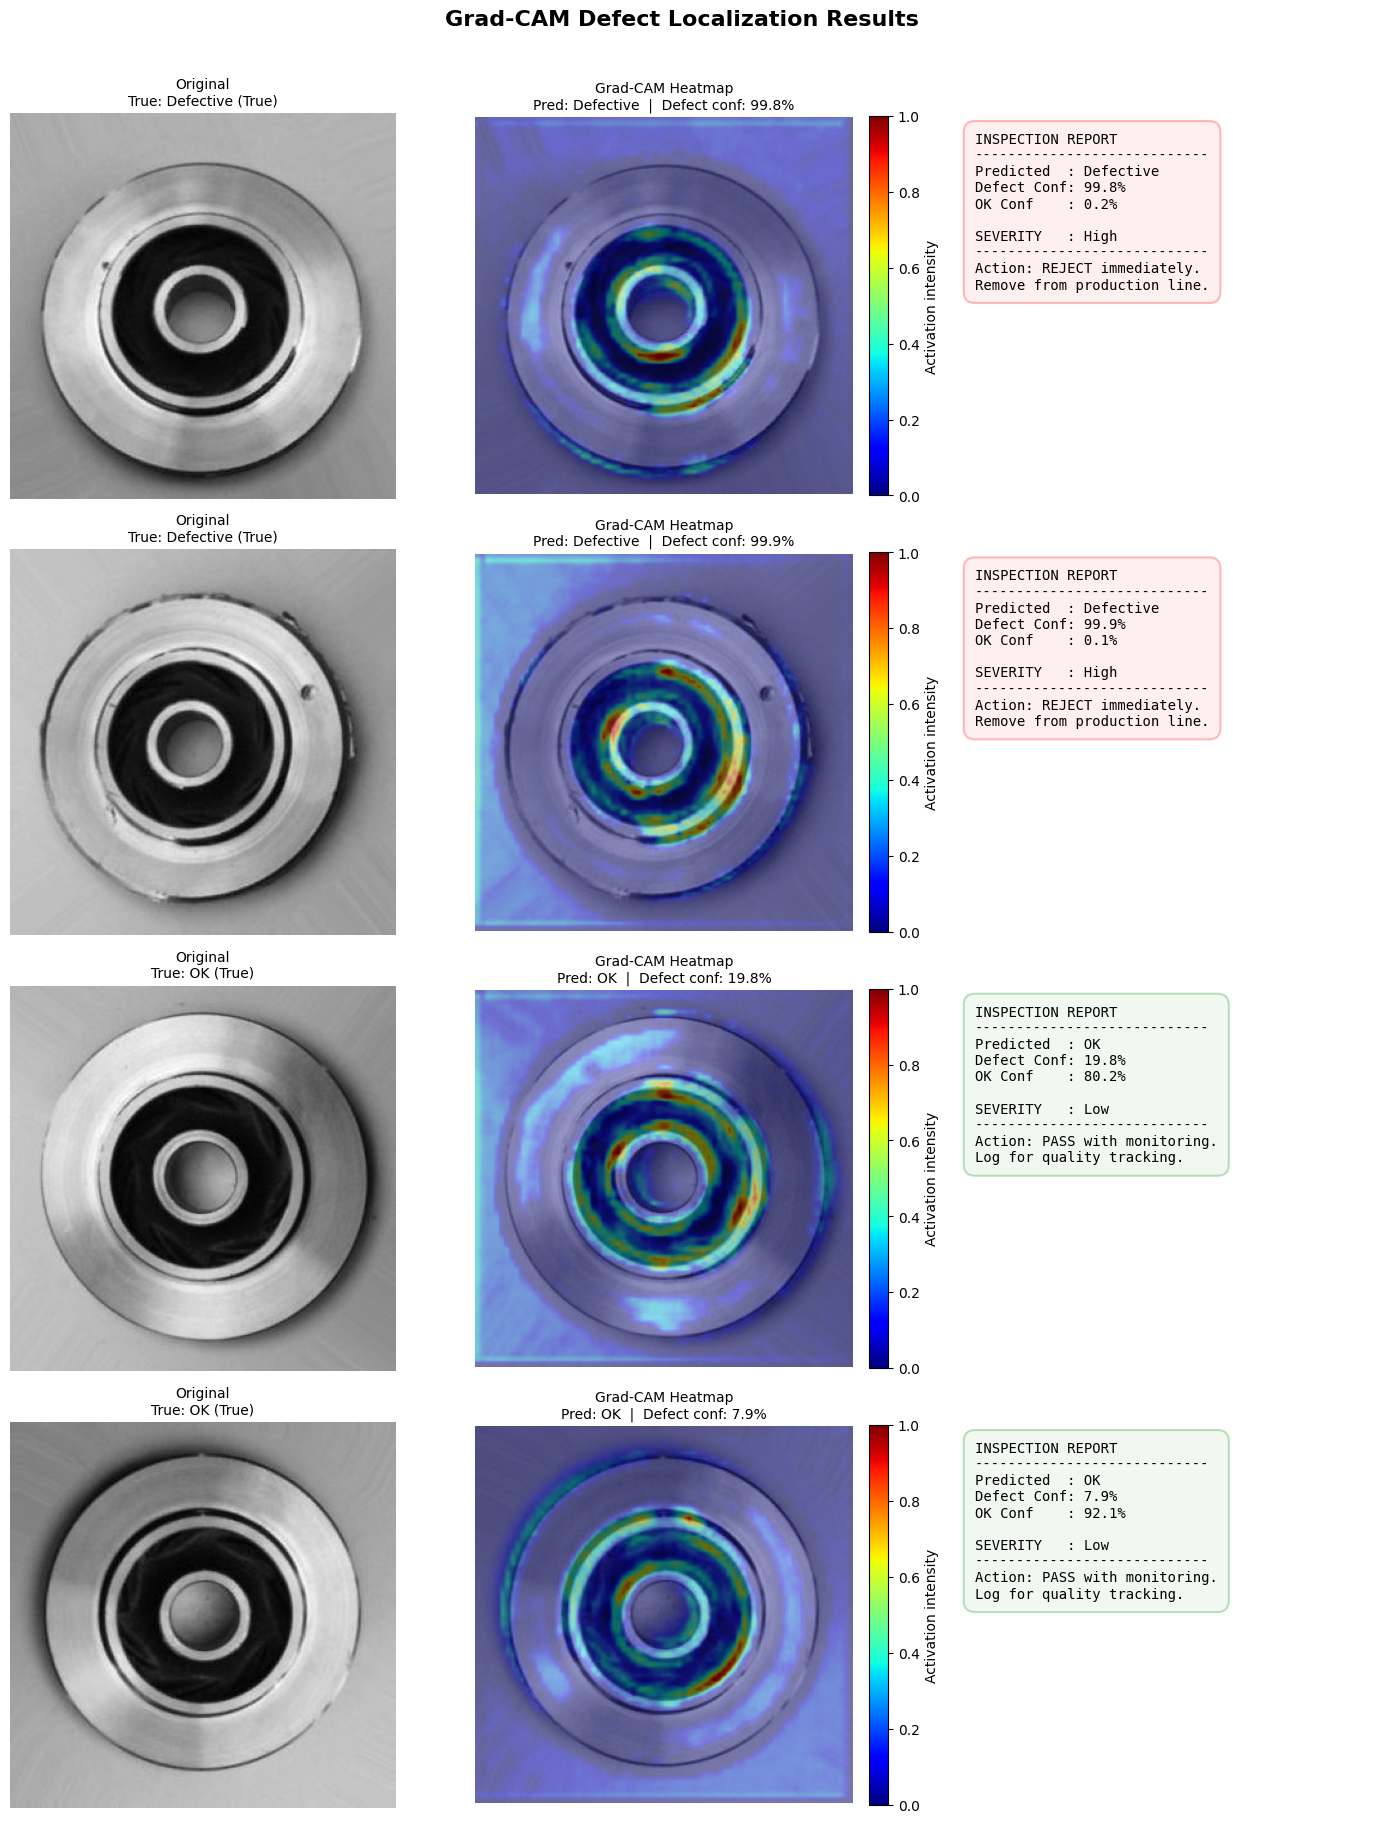

Saved: gradcam_results.png


In [ ]:
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.preprocessing.image import load_img, img_to_array


SEVERITY_COLORS  = {"High": "#FF4B4B", "Medium": "#FFA500", "Low": "#4CAF50"}
SEVERITY_ACTIONS = {
    "High":   "Action: REJECT immediately.\nRemove from production line.",
    "Medium": "Action: FLAG for manual review.\nInspect closely before passing.",
    "Low":    "Action: PASS with monitoring.\nLog for quality tracking.",
}

def assign_severity(prob_def):
    if prob_def >= 0.75:   return "High"
    elif prob_def >= 0.50: return "Medium"
    else:                  return "Low"


def collect_image_paths(n_per_case=2):
    test_dir   = os.path.join(DATA_DIR, "test")
    defect_dir = os.path.join(test_dir, "def_front")
    ok_dir     = os.path.join(test_dir, "ok_front")
    defect_paths = [os.path.join(defect_dir, f) for f in os.listdir(defect_dir)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    ok_paths     = [os.path.join(ok_dir, f) for f in os.listdir(ok_dir)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.seed(SEED)
    return {
        "defect": random.sample(defect_paths, min(n_per_case * 3, len(defect_paths))),
        "ok":     random.sample(ok_paths,     min(n_per_case * 3, len(ok_paths))),
    }


    img      = load_img(img_path, color_mode="grayscale", target_size=IMG_SIZE)
    img_arr  = img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_arr, axis=0)
    prob_ok  = float(model.predict(img_batch, verbose=0)[0][0])
    return img_arr, 1.0 - prob_ok


def make_gradcam_heatmap(img_batch, model):

    last_conv = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name


    _ = model(img_batch, training=False)

    grad_model = tf.keras.models.Model(
        inputs=model.layers[0].input,
        outputs=[model.get_layer(last_conv).output,
                 model.layers[-1].output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch, training=False)
        pred_class = tf.argmax(preds[0])
        loss = preds[:, pred_class]

    grads  = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam    = tf.reduce_sum(conv_out[0] * pooled, axis=-1).numpy()
    cam    = np.maximum(cam, 0)
    cam    = cam / (cam.max() + 1e-8)
    cam    = tf.image.resize(cam[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    return cam


def overlay_gradcam(img_arr, heatmap):
    import cv2
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    img_rgb = np.concatenate([img_arr, img_arr, img_arr], axis=-1)  # grayscale → RGB
    return np.clip(img_rgb * 0.6 + heatmap_color * 0.4, 0, 1)


dummy = np.zeros((1, *IMG_SIZE, 1))
model(dummy, training=False)


def visualize_gradcam_grid(n_samples=2):
    paths   = collect_image_paths(n_per_case=n_samples)
    samples = (
        [("Defective (True)", p) for p in paths["defect"][:n_samples]] +
        [("OK (True)",        p) for p in paths["ok"][:n_samples]]
    )
    n_rows = len(samples)
    fig, axes = plt.subplots(n_rows, 3, figsize=(14, 4.5 * n_rows))
    fig.suptitle("Grad-CAM Defect Localization Results",
                 fontsize=16, fontweight="bold", y=1.01)

    for row, (true_label, img_path) in enumerate(samples):
        img_arr, prob_def = predict_single(img_path)
        severity  = assign_severity(prob_def)
        sev_color = SEVERITY_COLORS[severity]
        pred_label = "Defective" if prob_def >= 0.5 else "OK"

        img_batch = np.expand_dims(img_arr, axis=0)
        heatmap   = make_gradcam_heatmap(img_batch, model)
        overlay   = overlay_gradcam(img_arr, heatmap)

        ax_orig, ax_cam, ax_info = axes[row]

        ax_orig.imshow(img_arr.squeeze(), cmap="gray")
        ax_orig.set_title(f"Original\nTrue: {true_label}", fontsize=10)
        ax_orig.axis("off")

        ax_cam.imshow(overlay)
        ax_cam.set_title(
            f"Grad-CAM Heatmap\nPred: {pred_label}  |  Defect conf: {prob_def*100:.1f}%",
            fontsize=10)
        ax_cam.axis("off")

        sm = plt.cm.ScalarMappable(cmap="jet", norm=plt.Normalize(0, 1))
        sm.set_array([])
        plt.colorbar(sm, ax=ax_cam, fraction=0.046, pad=0.04, label="Activation intensity")

        info = (
            f"INSPECTION REPORT\n"
            f"{'-'*28}\n"
            f"Predicted  : {pred_label}\n"
            f"Defect Conf: {prob_def*100:.1f}%\n"
            f"OK Conf    : {(1-prob_def)*100:.1f}%\n\n"
            f"SEVERITY   : {severity}\n"
            f"{'-'*28}\n"
            f"{SEVERITY_ACTIONS[severity]}"
        )
        ax_info.axis("off")
        ax_info.text(
            0.05, 0.95, info,
            transform=ax_info.transAxes,
            fontsize=10, verticalalignment="top",
            fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.8",
                      facecolor=sev_color + "15",
                      edgecolor=sev_color + "60",
                      linewidth=1.5)
        )

    plt.tight_layout()
    plt.savefig("gradcam_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: gradcam_results.png")

visualize_gradcam_grid(n_samples=2)

**SINGLE IMAGE INSPECTION**

Report saved: inspection_report_cast_def_0_302.png


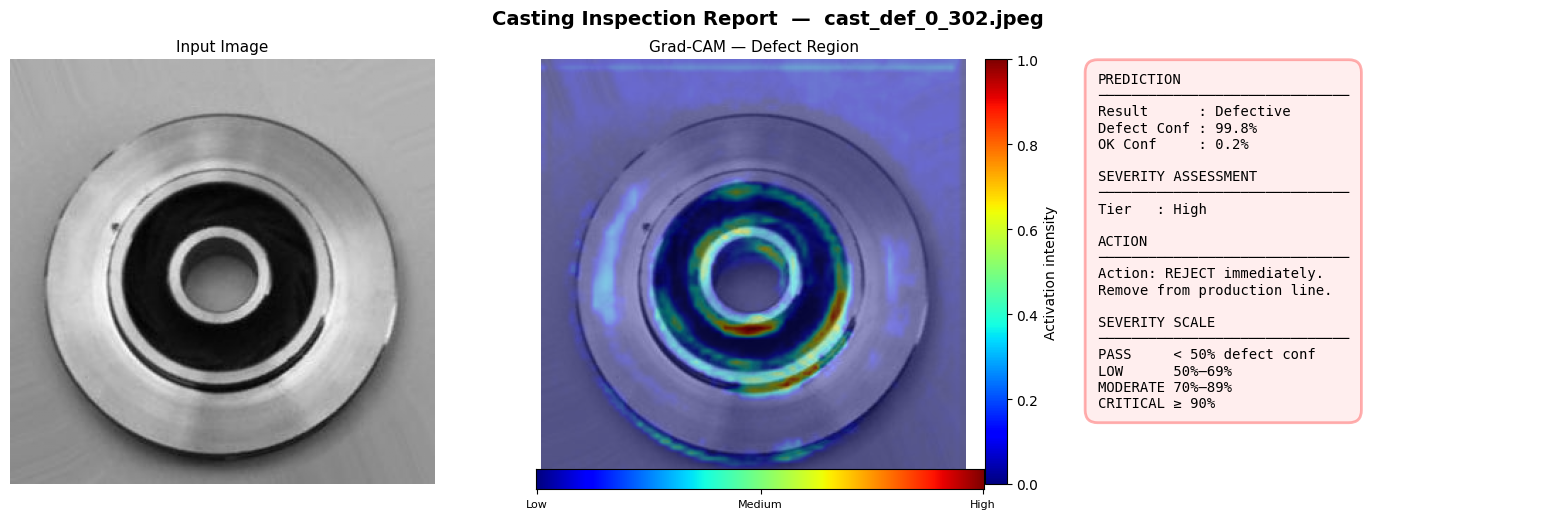


Inspection result:
  image_path                : casting_data/casting_data/test/def_front/cast_def_0_302.jpeg
  predicted_class           : Defective
  defect_confidence_pct     : 99.8
  ok_confidence_pct         : 0.2
  severity                  : High
  action                    : Action: REJECT immediately.
Remove from production line.


In [ ]:
# This is the production-ready function.
# In an industrial deployment, this would be exposed as an API endpoint.
# A camera captures a casting image → this function runs → result sent to PLC/dashboard.

def inspect_casting(img_path, model=model, show_plot=True, save_report=True):
    """
    Full defect inspection pipeline for one casting image.

    Args:
        img_path    : path to the image file (any standard format)
        model       : trained Keras model (default: global model)
        show_plot   : whether to display the report figure
        save_report : whether to save the figure to disk

    Returns:
        dict with keys:
            image_path, predicted_class, defect_confidence_pct,
            ok_confidence_pct, severity, action, heatmap, overlay
    """
    # ── Load & preprocess
    img     = load_img(img_path, color_mode="grayscale", target_size=IMG_SIZE)
    img_arr = img_to_array(img) / 255.0
    img_bat = np.expand_dims(img_arr, axis=0)

    # ── Predict
    prob_ok      = float(model.predict(img_bat, verbose=0)[0][0])
    prob_def     = 1.0 - prob_ok
    pred_label   = "Defective" if prob_def >= 0.5 else "OK"
    severity     = assign_severity(prob_def)
    sev_color    = SEVERITY_COLORS[severity]
    action       = SEVERITY_ACTIONS[severity]

    # ── GradCAM
    heatmap = make_gradcam_heatmap(img_bat, model)
    overlay = overlay_gradcam(img_arr, heatmap)

    if show_plot:
        fig = plt.figure(figsize=(16, 5))
        fig.suptitle(
            f"Casting Inspection Report  —  {os.path.basename(img_path)}",
            fontsize=14, fontweight="bold"
        )

        # Original
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.imshow(img_arr.squeeze(), cmap="gray")
        ax1.set_title("Input Image", fontsize=11)
        ax1.axis("off")

        # Grad-CAM
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.imshow(overlay)
        ax2.set_title("Grad-CAM — Defect Region", fontsize=11)
        ax2.axis("off")
        sm = plt.cm.ScalarMappable(cmap="jet", norm=plt.Normalize(0, 1))
        sm.set_array([])
        plt.colorbar(sm, ax=ax2, fraction=0.046, pad=0.04,
                     label="Activation intensity")

        # Heatmap intensity scale legend
        ax_leg = fig.add_axes([0.355, 0.02, 0.28, 0.04])
        gradient = np.linspace(0, 1, 256).reshape(1, -1)
        ax_leg.imshow(gradient, aspect="auto", cmap="jet")
        ax_leg.set_xticks([0, 128, 255])
        ax_leg.set_xticklabels(["Low", "Medium", "High"], fontsize=8)
        ax_leg.set_yticks([])

        # Report panel
        ax3 = fig.add_subplot(1, 3, 3)
        ax3.axis("off")
        report = (
            f"PREDICTION\n"
            f"{'─'*30}\n"
            f"Result      : {pred_label}\n"
            f"Defect Conf : {prob_def*100:.1f}%\n"
            f"OK Conf     : {prob_ok*100:.1f}%\n\n"
            f"SEVERITY ASSESSMENT\n"
            f"{'─'*30}\n"
            f"Tier   : {severity}\n\n"
            f"ACTION\n"
            f"{'─'*30}\n"
            f"{action}\n\n"
            f"SEVERITY SCALE\n"
            f"{'─'*30}\n"
            f"PASS     < 50% defect conf\n"
            f"LOW      50%–69%\n"
            f"MODERATE 70%–89%\n"
            f"CRITICAL ≥ 90%"
        )
        ax3.text(
            0.05, 0.97, report,
            transform=ax3.transAxes,
            fontsize=10, verticalalignment="top",
            fontfamily="monospace",
            bbox=dict(
                boxstyle="round,pad=0.9",
                facecolor=sev_color + "18",
                edgecolor=sev_color + "70",
                linewidth=2,
            )
        )

        plt.tight_layout()
        if save_report:
            out = "inspection_report_" + os.path.splitext(
                os.path.basename(img_path))[0] + ".png"
            plt.savefig(out, dpi=150, bbox_inches="tight")
            print(f"Report saved: {out}")
        plt.show()

    return {
        "image_path":          img_path,
        "predicted_class":     pred_label,
        "defect_confidence_pct": round(prob_def * 100, 1),
        "ok_confidence_pct":   round(prob_ok * 100, 1),
        "severity":            severity,
        "action":              action,
        "heatmap":             heatmap,
        "overlay":             overlay,
    }


# ── Quick demo: run on a random test image
demo_paths = collect_image_paths(n_per_case=3)
demo_img   = random.choice(demo_paths["defect"])

result = inspect_casting(demo_img)
print("\nInspection result:")
for k, v in result.items():
    if k not in ("heatmap", "overlay"):
        print(f"  {k:26s}: {v}")

**SAVE**

In [11]:
model.save("casting_defect_cnn_final.h5")
print("\n✓ Model saved: casting_defect_cnn_final.h5")

print("\nAll output files:")
outputs = [
    "training_curves.png",
    "evaluation.png",
    "precision_recall.png",
    "severity_distribution.png",
    "gradcam_results.png",
    "inspection_report_*.png",
    "casting_defect_cnn_final.h5",
]
for f in outputs:
    print(f"  {f}")

print("\n" + "="*60)
print("TO INSPECT ANY NEW IMAGE:")
print("  result = inspect_casting('your_image.jpg')")
print("  print(result['severity'], result['action'])")
print("="*60)


✓ Model saved: casting_defect_cnn_final.h5

All output files:
  training_curves.png
  evaluation.png
  precision_recall.png
  severity_distribution.png
  gradcam_results.png
  inspection_report_*.png
  casting_defect_cnn_final.h5

TO INSPECT ANY NEW IMAGE:
  result = inspect_casting('your_image.jpg')
  print(result['severity'], result['action'])


In [12]:

import os

# Check if file exists
if os.path.exists('casting_defect_cnn_final.h5'):
    print("✓ best_model.h5 found!")
    print(f"Size: {os.path.getsize('casting_defect_cnn_final.h5') / (1024*1024):.2f} MB")
else:
    print("❌ best_model.h5 not found")

# List all files in current directory
print("\nFiles in current directory:")
os.listdir()


✓ best_model.h5 found!
Size: 0.54 MB

Files in current directory:


['.config', 'casting_defect_cnn_final.h5', 'sample_data']